# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

Objective: Engineer a classification model to predict whether a retail banking customer will subscribe to a term deposit campaign, allowing the marketing team to optimize their phone outreach strategy.

Dataset: The Bank Marketing Dataset (containing demographic, financial, and previous campaign engagement metrics).

Approach:
1. Data Preprocessing: Converted text-based categorical variables into machine-readable numerical formats using Label Encoding (for the target) and One-Hot Encoding (for features).
2. Modeling: Trained a Random Forest Classifier (100 estimators) on an 80/20 train-test split.
3. Evaluation: Scored the model using classification metrics (Accuracy, Precision, Recall) and visualized the internal decision-making process using a Feature Importance bar chart.

In [1]:
# 1. Import the necessary data science libraries
import pandas as pd

print("Loading the Bank Marketing dataset... please wait.")

# 2. Load the dataset directly from a reliable public repository
url = 'https://raw.githubusercontent.com/Lexie88rus/bank-marketing-analysis/master/bank.csv'

# This dataset uses commas, so standard read_csv works perfectly
df = pd.read_csv(url)

# 3. Check our work
print("\n✅ SUCCESS! Data is perfectly loaded and ready.")
print("\n--- First 5 Rows of the Bank Marketing Dataset ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

Loading the Bank Marketing dataset... please wait.

✅ SUCCESS! Data is perfectly loaded and ready.

--- First 5 Rows of the Bank Marketing Dataset ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [2]:
from sklearn.preprocessing import LabelEncoder

print("Converting text data into numbers... please wait.")

# 1. Encode the Target Variable ('deposit')
# This changes 'yes' to 1 and 'no' to 0
le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])

# 2. Use One-Hot Encoding for the rest of the text categories (job, marital, etc.)
# pd.get_dummies automatically finds text columns and converts them to binary (1s and 0s)
# drop_first=True prevents mathematical redundancies (the "dummy variable trap")
df_numeric = pd.get_dummies(df, drop_first=True)

# 3. Check our work
print("\n✅ SUCCESS! All text has been converted to numbers.")
print(f"Old number of columns: {df.shape[1]}")
print(f"New number of columns: {df_numeric.shape[1]}")
print("\n--- First 5 Rows of the Numeric Dataset ---")

# Display all columns so we can see the transformation
pd.set_option('display.max_columns', None)
display(df_numeric.head())

Converting text data into numbers... please wait.

✅ SUCCESS! All text has been converted to numbers.
Old number of columns: 17
New number of columns: 43

--- First 5 Rows of the Numeric Dataset ---


,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Splitting data and training the Random Forest model... please wait.")

# 1. Define our "Features" (the clues) and our "Target" (the answer we want to predict)
X = df_numeric.drop('deposit', axis=1)
y = df_numeric['deposit']

# 2. Train/Test Split: Keep 80% to train, use 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest Classifier
# n_estimators=100 means we are building a "forest" of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Ask the model to predict the outcomes of the hidden 20% test customers
predictions = rf_model.predict(X_test)

# 5. Calculate the Accuracy Score
accuracy = accuracy_score(y_test, predictions)

print("\n✅ Random Forest Model Trained Successfully!")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 6. Print a detailed report card translating 0 and 1 back to business terms
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions, target_names=['No (Refused)', 'Yes (Subscribed)']))

Splitting data and training the Random Forest model... please wait.

✅ Random Forest Model Trained Successfully!
Overall Accuracy: 84.10%

--- Detailed Classification Report ---
                  precision    recall  f1-score   support

    No (Refused)       0.87      0.82      0.84      1166
Yes (Subscribed)       0.81      0.86      0.84      1067

        accuracy                           0.84      2233
       macro avg       0.84      0.84      0.84      2233
    weighted avg       0.84      0.84      0.84      2233



Calculating the top 10 most important customer clues... please wait.


/tmp/ipykernel_7127/2657593045.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='mako')


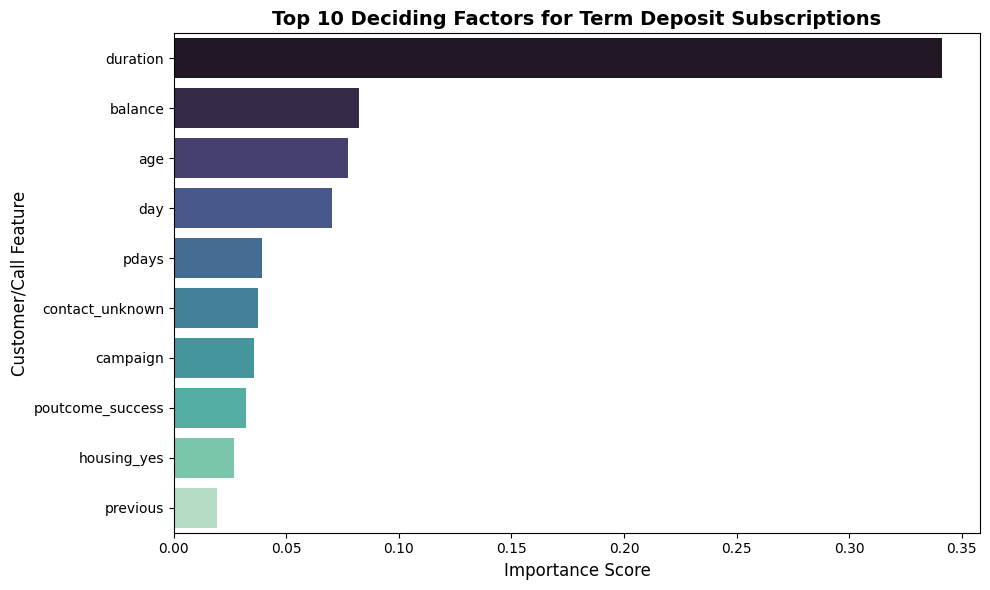

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Calculating the top 10 most important customer clues... please wait.")

# 1. Extract the importance scores directly from our trained Random Forest
importances = rf_model.feature_importances_

# 2. Match the math scores to the actual column names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. We only want to see the Top 10 so the chart isn't cluttered
top_10_features = feature_importance_df.head(10)

# 4. Draw a professional bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='mako')

plt.title('Top 10 Deciding Factors for Term Deposit Subscriptions', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Customer/Call Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Conclusion and Business Recommendation

The Random Forest classification engine achieved an 84.10% overall accuracy, with an impressive 86% recall rate for successfully identifying customers who actually want to subscribe.

Business Insight: By extracting the feature importance from the algorithm, we conclusively determined that `duration` (length of the phone call) and `balance` (existing capital) are the absolute dominant predictors of a successful sale.

Recommendation: The marketing department should transition away from high-volume random cold calling. Instead, they should filter their lead lists to prioritize high-balance customers. Furthermore, call center scripts should be optimized specifically to maximize initial call duration, as engagement time is the strongest indicator of conversion.